# 05. Modelagem de Classificação: Regressão Logística Binária de Fluxo Comercial

**Documentação da Etapa**
* **Objetivo da etapa:** Ajustar modelos de regressão logística binária ($Y \in \{0, 1\}$, onde $1 = \text{Exportação}$ e $0 = \text{Importação}$) para avaliar a capacidade preditiva do fluxo comercial a partir do volume físico, valor financeiro FOB e sazonalidade mensal.
* **Dados de entrada:** Base transacional tratada das rotas líderes (`data/processed/df_transacional_lideres.csv`).
* **Procedimentos realizados:**
  1. Configuração do ambiente e binarização da variável resposta (`Fluxo`).
  2. Ajuste e avaliação da Regressão Logística Simples (Opção 2: $Fluxo \sim \text{Volume\_FOB}$), cálculo do Ponto de Virada ($x^*$) e curva sigmoide em S.
  3. Ajuste e avaliação da Regressão Logística Múltipla com Sazonalidade (Opção 4: $Fluxo \sim \text{Valor\_FOB} + \text{Dummies\_Mês}$).
  4. Avaliação de desempenho nos três limiares de decisão ($c = 0.3$, $c = 0.5$ e $c = 0.7$) com Matrizes de Confusão, Acurácia, Precisão, Recall e Especificidade.
  5. Construção e diagnóstico gráfico da Curva ROC e cálculo da Área sob a Curva (AUC).

### Configurações

In [1]:
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(scales)
library(fs)

# Configuração da raiz do projeto
caminho_atual <- getwd()
raiz_projeto <- ifelse(basename(caminho_atual) == "notebooks", path_dir(caminho_atual), caminho_atual)

# Carrega módulos de modelagem
source(path(raiz_projeto, "R", "regressoes.R"))

# Carga da base transacional das rotas líderes (Top 1)
df_transacional <- read_csv2(
  path(raiz_projeto, "data", "processed", "df_transacional_lideres.csv"),
  show_col_types = FALSE
)

# Preparação dos dados binários (1 = Exportação, 0 = Importação)
df_logit <- preparar_dados_logistica(df_transacional)

cat(sprintf("Base de classificação preparada com %d registros.\n", nrow(df_logit)))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Base de classificação preparada com 481 registros.


## 1. Regressão Logística Simples por Volume Físico

### 1.1 Aplicação e Ajuste do Modelo Logístico Simples 

In [2]:
# Ajuste do Modelo Logístico Simples
res_opcao2 <- ajustar_logistica_opcao2(df_logit)

cat("=== RESUMO DO MODELO (LOGIT) ===\n")
print(res_opcao2$resumo)

cat("\n=== RAZÃO DE CHANCES (ODDS RATIO: exp(β)) ===\n")
print(res_opcao2$odds_ratio)

cat(sprintf("\n=== PONTO DE VIRADA (P = 0.5): x* = -β₀ / β₁ ===\n"))
cat(sprintf("x* = %.2f milhares de toneladas (%.2f toneladas)\n", 
            res_opcao2$ponto_virada_k_ton, 
            res_opcao2$ponto_virada_k_ton * 1e3))

=== RESUMO DO MODELO (LOGIT) ===

Call:
glm(formula = y ~ volume_mil_ton, family = binomial, data = df_logit)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.134865   0.165801  -6.845 7.66e-12 ***
volume_mil_ton  0.016866   0.002417   6.977 3.01e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 666.81  on 480  degrees of freedom
Residual deviance: 557.40  on 479  degrees of freedom
AIC: 561.4

Number of Fisher Scoring iterations: 6


=== RAZÃO DE CHANCES (ODDS RATIO: exp(β)) ===
   (Intercept) volume_mil_ton 
     0.3214654      1.0170088 

=== PONTO DE VIRADA (P = 0.5): x* = -β₀ / β₁ ===
x* = 67.29 milhares de toneladas (67288.10 toneladas)


### 1.2 Avaliação do Modelo Simples através de Limiares de Decisão e Curva Sigmoide

In [3]:
# Avaliação nos limiares 0.3, 0.5 e 0.7
aval_opcao2 <- avaliar_metricas_limiares(res_opcao2$modelo, df_logit)

cat("=== MÉTRICAS NOS TRÊS LIMIARES DE DECISÃO ===\n")
print(as.data.frame(aval_opcao2$metricas))

cat(sprintf("\nÁrea sob a Curva (AUC): %.4f\n", aval_opcao2$auc))

cat("\n--- Matriz de Confusão (Limiar c = 0.3) ---\n")
print(aval_opcao2$matrizes[["0.3"]])

cat("\n--- Matriz de Confusão (Limiar c = 0.5) ---\n")
print(aval_opcao2$matrizes[["0.5"]])

cat("\n--- Matriz de Confusão (Limiar c = 0.7) ---\n")
print(aval_opcao2$matrizes[["0.7"]])

=== MÉTRICAS NOS TRÊS LIMIARES DE DECISÃO ===
  Limiar Acurácia Precisão Recall (Sensibilidade) Especificidade  VP  FP  FN
1    0.3   0.4782   0.4866                 0.8292         0.1286 199 210  41
2    0.5   0.7214   0.8487                 0.5375         0.9046 129  23 111
3    0.7   0.6798   0.9886                 0.3625         0.9959  87   1 153
   VN
1  31
2 218
3 240

Área sob a Curva (AUC): 0.6750

--- Matriz de Confusão (Limiar c = 0.3) ---
    Previsto
Real   0   1
   0  31 210
   1  41 199

--- Matriz de Confusão (Limiar c = 0.5) ---
    Previsto
Real   0   1
   0 218  23
   1 111 129

--- Matriz de Confusão (Limiar c = 0.7) ---
    Previsto
Real   0   1
   0 240   1
   1 153  87


`geom_smooth()` using formula = 'y ~ x'


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


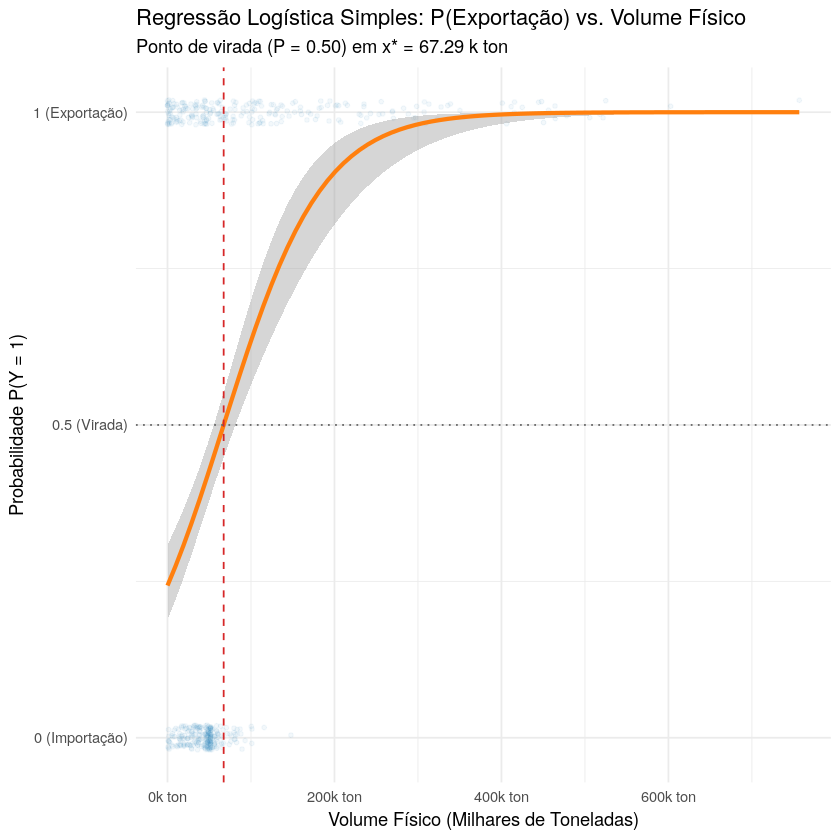

In [4]:
# Gráfico da Curva Sigmoide com Ponto de Virada (P = 0.50)
p_sigmoide <- ggplot(df_logit, aes(x = volume_mil_ton, y = y)) +
  geom_point(alpha = 0.05, color = "#1f77b4", size = 1, position = position_jitter(height = 0.02)) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), color = "#ff7f0e", linewidth = 1.2) +
  geom_vline(xintercept = res_opcao2$ponto_virada_k_ton, linetype = "dashed", color = "#d62728") +
  geom_hline(yintercept = 0.5, linetype = "dotted", color = "gray40") +
  scale_y_continuous(breaks = c(0, 0.5, 1), labels = c("0 (Importação)", "0.5 (Virada)", "1 (Exportação)")) +
  scale_x_continuous(labels = label_number(suffix = "k ton", big.mark = ".")) +
  labs(
    title = "Regressão Logística Simples: P(Exportação) vs. Volume Físico",
    subtitle = sprintf("Ponto de virada (P = 0.50) em x* = %.2f k ton", res_opcao2$ponto_virada_k_ton),
    x = "Volume Físico (Milhares de Toneladas)",
    y = "Probabilidade P(Y = 1)"
  ) +
  theme_minimal()

print(p_sigmoide)

## 2. Regressão Logística com Valor FOB e Sazonalidade 

### 2.1 Aplicação e Ajuste do Modelo Múltiplo Sazonal

In [5]:
# Ajuste da Opção 4: Valor FOB + Dummies de Mês (Janeiro como base)
res_opcao4 <- ajustar_logistica_opcao4(df_logit)

cat("=== COEFICIENTES NA ESCALA DO LOGIT (β) ===\n")
print(summary(res_opcao4$modelo)$coefficients)

cat("\n=== RAZÃO DE CHANCES POR MÊS E VALOR (ODDS RATIO = exp(β)) ===\n")
print(round(res_opcao4$odds_ratio, 4))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


=== COEFICIENTES NA ESCALA DO LOGIT (β) ===
                      Estimate Std. Error     z value     Pr(>|z|)
(Intercept)        -1.38099009 0.38816882 -3.55770483 3.741094e-04
valor_milhoes_fob   0.12357976 0.01377213  8.97317713 2.880823e-19
mes_fatorFevereiro -0.42038766 0.54408763 -0.77264698 4.397313e-01
mes_fatorMarço     -2.07217156 0.70562286 -2.93665594 3.317720e-03
mes_fatorAbril     -1.38148443 0.69327567 -1.99269134 4.629526e-02
mes_fatorMaio      -1.60163345 0.66348423 -2.41397364 1.577960e-02
mes_fatorJunho     -1.22786839 0.61943036 -1.98225413 4.745081e-02
mes_fatorJulho     -0.95792583 0.57691639 -1.66042400 9.682918e-02
mes_fatorAgosto    -0.40298962 0.55976144 -0.71993101 4.715675e-01
mes_fatorSetembro  -0.24103010 0.55520775 -0.43412596 6.641970e-01
mes_fatorOutubro   -0.25765502 0.54641263 -0.47153928 6.372557e-01
mes_fatorNovembro   0.45340262 0.54190892  0.83667680 4.027743e-01
mes_fatorDezembro   0.01806804 0.55227030  0.03271593 9.739011e-01

=== RAZÃO DE CHAN

### 2.2 Avaliação do Modelo Múltiplo através de Limiares de Decisão e Curva ROC

In [6]:
# Avaliação nos limiares 0.3, 0.5 e 0.7
aval_opcao4 <- avaliar_metricas_limiares(res_opcao4$modelo, df_logit)

cat("=== MÉTRICAS DA OPÇÃO 4 (VALOR FOB + SAZONALIDADE) ===\n")
print(as.data.frame(aval_opcao4$metricas))

cat(sprintf("\nÁrea sob a Curva (AUC) da Opção 4: %.4f\n", aval_opcao4$auc))

cat("\n--- Matriz de Confusão (Limiar c = 0.3) ---\n")
print(aval_opcao4$matrizes[["0.3"]])

cat("\n--- Matriz de Confusão (Limiar c = 0.5) ---\n")
print(aval_opcao4$matrizes[["0.5"]])

cat("\n--- Matriz de Confusão (Limiar c = 0.7) ---\n")
print(aval_opcao4$matrizes[["0.7"]])

=== MÉTRICAS DA OPÇÃO 4 (VALOR FOB + SAZONALIDADE) ===
  Limiar Acurácia Precisão Recall (Sensibilidade) Especificidade  VP FP FN  VN
1    0.3   0.7505   0.7083                 0.8500         0.6515 204 84 36 157
2    0.5   0.8025   0.8607                 0.7208         0.8838 173 28 67 213
3    0.7   0.7900   0.9371                 0.6208         0.9585 149 10 91 231

Área sob a Curva (AUC) da Opção 4: 0.8831

--- Matriz de Confusão (Limiar c = 0.3) ---
    Previsto
Real   0   1
   0 157  84
   1  36 204

--- Matriz de Confusão (Limiar c = 0.5) ---
    Previsto
Real   0   1
   0 213  28
   1  67 173

--- Matriz de Confusão (Limiar c = 0.7) ---
    Previsto
Real   0   1
   0 231  10
   1  91 149


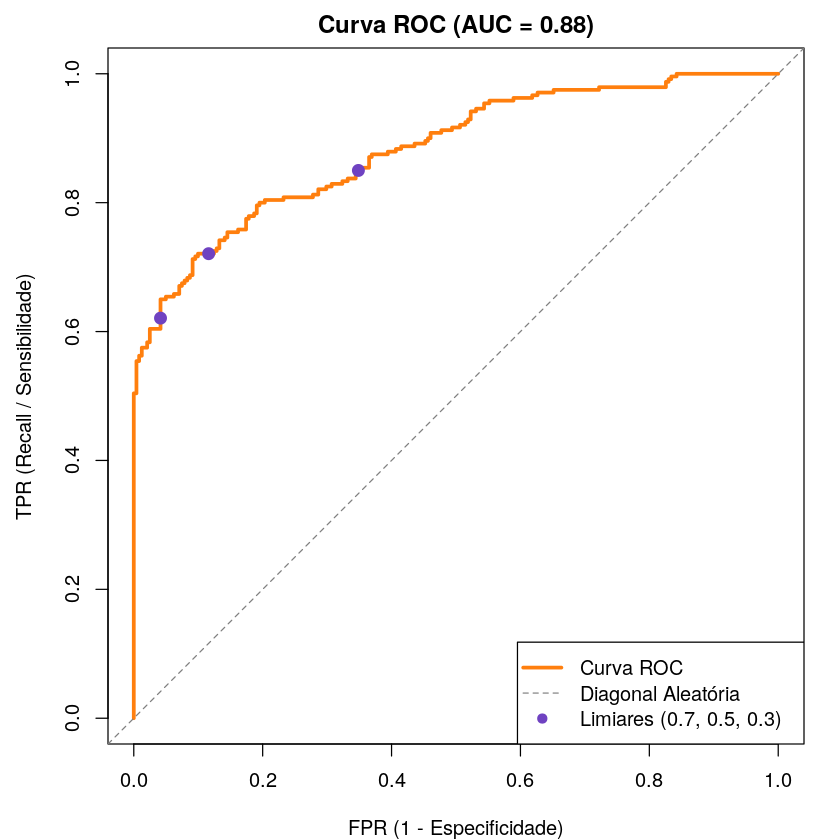

In [7]:
# Gráfico da Curva ROC com destaque nos limiares 0.3, 0.5 e 0.7
p_vals <- aval_opcao4$probabilidades
y_vals <- df_logit$y

ord <- order(p_vals, decreasing = TRUE)
tpr <- cumsum(y_vals[ord]) / sum(y_vals)
fpr <- cumsum(1 - y_vals[ord]) / sum(1 - y_vals)

par(mar = c(4, 4, 2, 1), pty = "s")
plot(c(0, fpr), c(0, tpr), type = "l", lwd = 3, col = "#ff7f0e",
     xlab = "FPR (1 - Especificidade)", ylab = "TPR (Recall / Sensibilidade)",
     main = sprintf("Curva ROC (AUC = %.2f)", aval_opcao4$auc))
abline(0, 1, lty = 2, col = "gray50")

# Destaque dos 3 limiares
for (L in c(0.7, 0.5, 0.3)) {
  points(mean(p_vals[y_vals == 0] > L), mean(p_vals[y_vals == 1] > L),
         pch = 19, cex = 1.3, col = "#6f42c1")
}
legend("bottomright", legend = c("Curva ROC", "Diagonal Aleatória", "Limiares (0.7, 0.5, 0.3)"),
       col = c("#ff7f0e", "gray50", "#6f42c1"), lty = c(1, 2, NA), pch = c(NA, NA, 19), lwd = c(3, 1, NA))